# Ensamble Learning

## Theory Questions

### Q.1. Can we use Bagging for regression problems?

--> Yes. Bagging can be used for regression. It trains multiple regression models on different bootstrap samples and averages their predictions to reduce variance and improve stability.

### Q.2. What is the difference between multiple model training and single model training?

--> Single model training uses one algorithm to make predictions.

--> Multiple model training (ensemble) combines predictions from several models to achieve better accuracy and robustness.

### Q.3. Explain the concept of feature randomness in Random Forest.

--> In Random Forest, each split considers only a random subset of features instead of all features. This reduces correlation between trees and improves generalization.

### Q.4. What is OOB (Out-of-Bag) Score?

--> OOB score is an internal validation metric in Bagging and Random Forest. It evaluates model performance using data samples not included in bootstrap training.

### Q.5. How can you measure the importance of features in a Random Forest model?

--> Feature importance is measured by how much a feature reduces impurity (Gini or MSE) across all trees in the forest.

### Q.6. Explain the working principle of a Bagging Classifier.

--> A Bagging Classifier trains multiple classifiers on different bootstrap samples and predicts the final output using majority voting.

### Q.7. How do you evaluate a Bagging Classifier’s performance?

--> Using metrics such as accuracy, precision, recall, F1-score, ROC-AUC, and cross-validation.

### Q.8. How does a Bagging Regressor work?

--> It trains multiple regression models on bootstrap samples and outputs the average of their predictions.

### Q.9. What is the main advantage of ensemble techniques?

--> They improve prediction accuracy and reduce overfitting by combining multiple models.

### Q.10. What is the main challenge of ensemble methods?

--> They increase computational cost, complexity, and reduce interpretability.

### Q.11. Explain the key idea behind ensemble techniques.

--> The key idea is to combine multiple weak learners to form a strong learner with better performance.

### Q.12. What is a Random Forest Classifier?

--> It is an ensemble algorithm that builds multiple decision trees using bagging and feature randomness and predicts using majority voting.

### Q.13. What are the main types of ensemble techniques?

--> Bagging

--> Boosting

--> Stacking

### Q.14. What is ensemble learning in machine learning?

--> Ensemble learning is a technique that combines predictions from multiple models to improve accuracy and robustness.

### Q.15. When should we avoid using ensemble methods?

--> When the dataset is small, interpretability is required, or computational resources are limited.

### Q.16. How does Bagging help in reducing overfitting?

--> Bagging reduces overfitting by averaging predictions from multiple models trained on different data samples, lowering variance.

### Q.17.  Why is Random Forest better than a single Decision Tree?

--> Random Forest reduces overfitting, improves accuracy, and handles noise better than a single Decision Tree.

### Q.18. What is the role of bootstrap sampling in Bagging?

--> Bootstrap sampling creates diverse training datasets by sampling with replacement, enabling model diversity.

### Q.19. What are some real-world applications of ensemble techniques?

--> Fraud detection

--> Medical diagnosis

--> Stock price prediction

--> Recommendation systems

--> Image classification

### Q.20.  What is the difference between Bagging and Boosting?

--> Bagging
> Reduces variance
          
> Models trained independently 

> Equal weight to all models   

--> Boosting
> Reduces bias

> Models trained sequentially

> Higher weight to misclassified samples

## Practical Questions

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_diabetes, make_classification, make_regression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import BaggingClassifier, BaggingRegressor, RandomForestClassifier, RandomForestRegressor, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, roc_auc_score, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

### Q.21. Train a Bagging Classifier using Decision Trees on a sample dataset and print model accuracy.

In [14]:
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

bag_clf = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)
print("Bagging Classifier Accuracy:", accuracy_score(y_test, y_pred))

Bagging Classifier Accuracy: 0.87


### Q.22. Train a Bagging Regressor using Decision Trees and evaluate using Mean Squared Error (MSE).

In [15]:
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

bag_reg = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=50, random_state=42)
bag_reg.fit(X_train, y_train)
y_pred = bag_reg.predict(X_test)
print("Bagging Regressor MSE:", mean_squared_error(y_test, y_pred))

Bagging Regressor MSE: 2987.0073593984966


### Q.23. Train a Random Forest Classifier on the Breast Cancer dataset and print feature importance scores.

In [16]:
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

print("Feature Importance Scores:")
for i in indices:
    print(f"{feature_names[i]:<35} {importances[i]:.4f}")

Feature Importance Scores:
mean concave points                 0.1419
worst concave points                0.1271
worst area                          0.1182
mean concavity                      0.0806
worst radius                        0.0780
worst perimeter                     0.0743
mean perimeter                      0.0601
mean area                           0.0538
worst concavity                     0.0411
mean radius                         0.0323
area error                          0.0295
worst texture                       0.0188
worst compactness                   0.0175
radius error                        0.0164
worst symmetry                      0.0129
perimeter error                     0.0118
worst smoothness                    0.0118
mean texture                        0.0111
mean compactness                    0.0092
fractal dimension error             0.0071
worst fractal dimension             0.0069
mean smoothness                     0.0062
smoothness error           

### Q.24. Train a Random Forest Regressor and compare its performance with a single Decision Tree.

In [17]:
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train, y_train)
dt_mse = mean_squared_error(y_test, dt_reg.predict(X_test))

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
rf_mse = mean_squared_error(y_test, rf_reg.predict(X_test))

print(f"Single Decision Tree MSE: {dt_mse:.2f}")
print(f"Random Forest Regressor MSE: {rf_mse:.2f}")
print(f"Improvement: {(dt_mse - rf_mse)/dt_mse * 100:.1f} % better")

Single Decision Tree MSE: 5697.79
Random Forest Regressor MSE: 2859.64
Improvement: 49.8 % better


### Q.25. Compute the Out-of-Bag (OOB) Score for a Random Forest Classifier.

In [18]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf.fit(X_train, y_train)

print("OOB Score:", rf.oob_score_)
print("Test Accuracy:", rf.score(X_test, y_test))

OOB Score: 0.9547738693467337
Test Accuracy: 0.9707602339181286


### Q.26. Train a Bagging Classifier using SVM as a base estimator and print accuracy.

In [19]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

bag_svm = BaggingClassifier(estimator=SVC(probability=True), n_estimators=20, random_state=42)
bag_svm.fit(X_train, y_train)
print("Bagging SVM Accuracy:", bag_svm.score(X_test, y_test))

Bagging SVM Accuracy: 0.9473684210526315


### Q.27. Train a Random Forest Classifier with different numbers of trees and compare accuracy.

In [20]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

n_trees = [10, 50, 100, 200, 500]
accuracies = []

for n in n_trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    acc = rf.score(X_test, y_test)
    accuracies.append(acc)
    print(f"n_estimators={n:3d} --> Accuracy: {acc:.4f}")

n_estimators= 10 --> Accuracy: 0.9649
n_estimators= 50 --> Accuracy: 0.9708
n_estimators=100 --> Accuracy: 0.9708
n_estimators=200 --> Accuracy: 0.9708
n_estimators=500 --> Accuracy: 0.9708


### Q.28. Train a Bagging Classifier using Logistic Regression as a base estimator and print AUC score.

In [22]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

bag_lr = BaggingClassifier(estimator=LogisticRegression(max_iter=100), n_estimators=30, random_state=42)
bag_lr.fit(X_train, y_train)

y_prob = bag_lr.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print("Bagging Logistic Regression AUC:", auc)

Bagging Logistic Regression AUC: 0.998236331569665


### Q.29. Train a Random Forest Regressor and analyze feature importance scores.

In [23]:
data = load_diabetes()
X, y = data.data, data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

importances = rf_reg.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

print("Top Features (Random Forest Regressor):")
for i in sorted_idx[:10]:
    print(f"{feature_names[i]:<20} {importances[i]:.4f}")

Top Features (Random Forest Regressor):
bmi                  0.4000
s5                   0.1666
bp                   0.1048
s6                   0.0714
s3                   0.0617
age                  0.0586
s1                   0.0492
s2                   0.0471
s4                   0.0294
sex                  0.0111


### Q.30. Train an ensemble model using both Bagging and Random Forest and compare accuracy.

In [24]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

bag = BaggingClassifier(n_estimators=50, random_state=42)
rf = RandomForestClassifier(n_estimators=50, random_state=42)

bag.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("Bagging Accuracy:", bag.score(X_test, y_test))
print("Random Forest Accuracy:", rf.score(X_test, y_test))

Bagging Accuracy: 0.9590643274853801
Random Forest Accuracy: 0.9707602339181286


### Q.31. Train a Random Forest Classifier and tune hyperparameters using GridSearchCV.

In [25]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)
grid = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)
print("Test accuracy:", grid.score(X_test, y_test))

Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best CV accuracy: 0.9497151898734177
Test accuracy: 0.9590643274853801


### Q.32. Train a Bagging Regressor with different numbers of base estimators and compare performance.

In [27]:
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

n_estimators_list = [10, 30, 50, 100, 200]
mses = []

for n in n_estimators_list:
    bag = BaggingRegressor(n_estimators=n, random_state=42)
    bag.fit(X_train, y_train)
    mse = mean_squared_error(y_test, bag.predict(X_test))
    mses.append(mse)
    print(f"n_estimators={n:3d} --> MSE: {mse:.2f}")

n_estimators= 10 --> MSE: 3237.53
n_estimators= 30 --> MSE: 2924.82
n_estimators= 50 --> MSE: 2987.01
n_estimators=100 --> MSE: 2908.81
n_estimators=200 --> MSE: 2854.88


### Q.33. Train a Random Forest Classifier and analyze misclassified samples.

In [29]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

misclassified_idx = np.where(y_pred != y_test)[0]
print(f"Number of misclassified samples: {len(misclassified_idx)} / {len(y_test)}")

Number of misclassified samples: 5 / 171


### Q.34. Train a Bagging Classifier and compare its performance with a single Decision Tree Classifier.

In [30]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_acc = dt.score(X_test, y_test)

bag = BaggingClassifier(n_estimators=50, random_state=42)
bag.fit(X_train, y_train)
bag_acc = bag.score(X_test, y_test)

print(f"Single DT Accuracy: {dt_acc:.4f}")
print(f"Bagging Accuracy: {bag_acc:.4f}")

Single DT Accuracy: 0.9415
Bagging Accuracy: 0.9591


### Q.35. Train a Random Forest Classifier and visualize the confusion matrix.

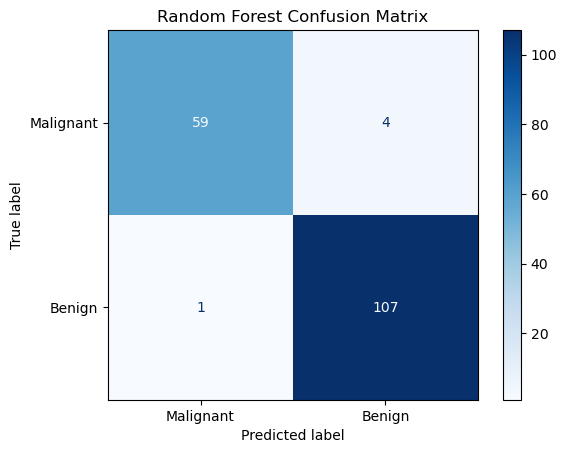

In [31]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Malignant", "Benign"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix")
plt.show()

### Q.36. Train a Stacking Classifier using Decision Trees, SVM, and Logistic Regression, and compare accuracy.

In [33]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

estimators = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('svm', SVC(probability=True, random_state=42)),
    ('lr', LogisticRegression(max_iter=1000))
]

stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=5)
stack.fit(X_train, y_train)

print("Stacking Classifier Accuracy:", stack.score(X_test, y_test))

Stacking Classifier Accuracy: 0.9766081871345029


### Q.37. Train a Random Forest Classifier and print the top 5 most important features.

In [34]:
data = load_breast_cancer()
X, y = data.data, data.target
features = data.feature_names

X_train, _, y_train, _ = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("Top 5 most important features:")
print(imp.head(5))

Top 5 most important features:
mean concave points     0.141934
worst concave points    0.127136
worst area              0.118217
mean concavity          0.080557
worst radius            0.077975
dtype: float64


### Q.38. Train a Bagging Classifier and evaluate performance using Precision, Recall, and F1-score.

In [35]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

bag = BaggingClassifier(n_estimators=50, random_state=42)
bag.fit(X_train, y_train)
y_pred = bag.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Malignant", "Benign"]))

              precision    recall  f1-score   support

   Malignant       0.95      0.94      0.94        63
      Benign       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



### Q.39. Train a Random Forest Classifier and analyze the effect of max_depth on accuracy.

In [37]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

depths = [None, 5, 10, 15, 20, 30]
accs = []

for d in depths:
    rf = RandomForestClassifier(max_depth=d, n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    acc = rf.score(X_test, y_test)
    accs.append(acc)
    print(f"max_depth = {d} --> Accuracy: {acc:.4f}")

max_depth = None --> Accuracy: 0.9708
max_depth = 5 --> Accuracy: 0.9649
max_depth = 10 --> Accuracy: 0.9708
max_depth = 15 --> Accuracy: 0.9708
max_depth = 20 --> Accuracy: 0.9708
max_depth = 30 --> Accuracy: 0.9708


### Q.40. Train a Bagging Regressor using different base estimators (DecisionTree and KNeighbors) and compare performance.

In [38]:
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

bag_dt = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=50, random_state=42)
bag_knn = BaggingRegressor(estimator=KNeighborsRegressor(), n_estimators=50, random_state=42)

bag_dt.fit(X_train, y_train)
bag_knn.fit(X_train, y_train)

print("Bagging + DT MSE:", mean_squared_error(y_test, bag_dt.predict(X_test)))
print("Bagging + KNN MSE:", mean_squared_error(y_test, bag_knn.predict(X_test)))

Bagging + DT MSE: 2987.0073593984966
Bagging + KNN MSE: 3140.186131007519


### Q.41. Train a Random Forest Classifier and evaluate its performance using ROC-AUC Score.

In [39]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_prob = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print("Random Forest ROC-AUC:", auc)

Random Forest ROC-AUC: 0.9968400940623163


### Q.42. Train a Bagging Classifier and evaluate its performance using cross-validation.

In [40]:
X, y = load_breast_cancer(return_X_y=True)

bag = BaggingClassifier(n_estimators=50, random_state=42)
scores = cross_val_score(bag, X, y, cv=5, scoring='accuracy')

print("Cross-validation accuracies:", scores)
print("Mean CV Accuracy:", scores.mean())
print("Std CV Accuracy:", scores.std())

Cross-validation accuracies: [0.9122807  0.92105263 0.98245614 0.95614035 1.        ]
Mean CV Accuracy: 0.9543859649122808
Std CV Accuracy: 0.033928209834760914


### Q.43. Train a Random Forest Classifier and plot the Precision-Recall curve.

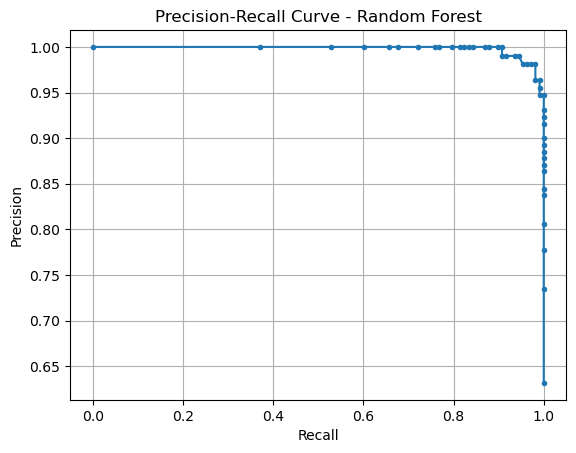

In [41]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_prob = rf.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Random Forest')
plt.grid(True)
plt.show()

### Q.44. Train a Stacking Classifier with Random Forest and Logistic Regression and compare accuracy.

In [42]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

estimators = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('lr', LogisticRegression(max_iter=1000))
]

stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=5)
stack.fit(X_train, y_train)

print("Stacking (RF + LR) Accuracy:", stack.score(X_test, y_test))

lr = LogisticRegression(max_iter=1000).fit(X_train, y_train)
print("Single LR Accuracy:     ", lr.score(X_test, y_test))

Stacking (RF + LR) Accuracy: 0.9707602339181286
Single LR Accuracy:      0.9707602339181286


### Q.45. Train a Bagging Regressor with different levels of bootstrap samples and compare performance.

In [43]:
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

bootstrap_options = [True, False]
max_samples_list = [0.5, 0.8, 1.0]

for boot in bootstrap_options:
    for frac in max_samples_list:
        bag = BaggingRegressor(n_estimators=50, bootstrap=boot, max_samples=frac, random_state=42)
        bag.fit(X_train, y_train)
        mse = mean_squared_error(y_test, bag.predict(X_test))
        print(f"bootstrap={boot}, max_samples={frac} --> MSE: {mse:.2f}")

bootstrap=True, max_samples=0.5 --> MSE: 2826.94
bootstrap=True, max_samples=0.8 --> MSE: 2831.03
bootstrap=True, max_samples=1.0 --> MSE: 2987.01
bootstrap=False, max_samples=0.5 --> MSE: 2881.75
bootstrap=False, max_samples=0.8 --> MSE: 3347.89
bootstrap=False, max_samples=1.0 --> MSE: 5190.68
